In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import ruamel.yaml
import math
import numpy as np
import tarfile
from matplotlib import cm
from matplotlib import pyplot as plt
import warnings
import yaml
yaml_format = ruamel.yaml.YAML()
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter  # Add this import at the top
import pickle  # Add this import at the top



import matplotlib.ticker as ticker  # Add this import at the top


In [11]:
def get_data_dir(subfolder):
    # current_dir = os.path.dirname(os.path.abspath(__file__))
    current_dir = os.getcwd()
    print(current_dir)
    return os.path.join(current_dir, "experiment_data", subfolder)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tarfile
import pandas as pd
from scipy.interpolate import interp1d

plt.rcParams.update({
    'font.size': 8,
    "font.weight": "bold",
    'axes.labelsize': 'large',
    'axes.labelweight': 'bold'
})

def compute_energy_consump(test_data_frame):
    total_energy = 0
    for i, t in enumerate(test_data_frame['average_power']['elapsed_time'].iloc[:-1]):
        total_energy += test_data_frame['average_power']['average_power'].iloc[i] * \
                        (test_data_frame['average_power']['elapsed_time'].iloc[i+1] -
                         test_data_frame['average_power']['elapsed_time'].iloc[i])
    return total_energy

# Set up figure and average containers
fig_phase, axs_phase = plt.subplots(3, 1, figsize=(10, 6))

# Define a common time axis
common_time = np.linspace(0, 90, 500)

# Containers for interpolation results
progress_all, power_all, pcap_all = [], [], []

experiments = {'plotting_data_old': 'k'}
average_energy = 0
average_ET = 0

for dirs in experiments.keys():
    label_val = "Proposed Controller" if 'Control' in dirs else "Uncapped"
    DATA_DIR = get_data_dir(dirs)
    root, folders, files = next(os.walk(DATA_DIR))
    test_results = {}

    for APP in folders:
        if APP == 'ones-stream-full':
            APP_DIR = os.path.join(DATA_DIR, APP)
            test_results[APP] = {}

            for tar_file in next(os.walk(APP_DIR))[2]:
                test_results[APP][tar_file] = {}

                if tar_file.endswith('.tar'):
                    tar_path = os.path.join(APP_DIR, tar_file)
                    extract_dir = os.path.join(APP_DIR, tar_file[:-4])

                    if not os.path.exists(extract_dir):
                        os.makedirs(extract_dir)
                        with tarfile.open(tar_path, 'r') as tar:
                            tar.extractall(path=extract_dir)

                    # Load data
                    pubProgress = pd.read_csv(f'{extract_dir}/progress.csv')
                    pubEnergy = pd.read_csv(f'{extract_dir}/energy.csv')
                    pubPAPI = pd.read_csv(f'{extract_dir}/papi.csv')
                    pubPCAP = pd.read_csv(f'{extract_dir}/PCAP_file.csv')
                    pubPower = pd.read_csv(f'{extract_dir}/measured_power.csv')

                    # Process data
                    test_results[APP][tar_file]['energy'] = pubEnergy
                    test_results[APP][tar_file]['power'] = compute_power(pubEnergy)
                    test_results[APP][tar_file]['progress'] = measure_progress(pubProgress, test_results[APP][tar_file]['power'])
                    test_results[APP][tar_file]['papi'] = collect_papi(pubPAPI)
                    test_results[APP][tar_file]['PCAP'] = generate_PCAP(pubPCAP)
                    test_results[APP][tar_file]['sensed_power'] = collect_power(pubPower)

                    # Extract series
                    stop = -1
                    progress_df = test_results[APP][tar_file]['progress']['progress_frequency_median']
                    power_df = test_results[APP][tar_file]['sensed_power']['average_power']
                    pcap_df = test_results[APP][tar_file]['PCAP']

                    # Filter and plot as line plots (not scatter)
                    valid_progress = progress_df[progress_df['median'] >= 0]
                    valid_power = power_df[power_df['average_power'] >= 0]
                    valid_pcap = pcap_df[pcap_df['value'] >= 0]

                axs_phase[0].plot(valid_progress['elapsed_time'].iloc[:stop], valid_progress['median'].iloc[:stop], alpha=0.3, linewidth=1)
                axs_phase[1].plot(valid_power['elapsed_time'], valid_power['average_power'], alpha=0.3, linewidth=1)
                axs_phase[2].plot(valid_pcap['elapsed_time'].iloc[:stop], valid_pcap['value'].iloc[:stop], alpha=0.3, linewidth=1)
                # print(valid_pcap['elapsed_time'].iloc[-1])
                if valid_pcap['elapsed_time'].iloc[-1] > 150:
                    print(tar_file)
                # Interpolate for averaging

                progress_interp = interp1d(progress_df['elapsed_time'], progress_df['median'], bounds_error=False, fill_value='extrapolate')
                power_interp = interp1d(power_df['elapsed_time'], power_df['average_power'], bounds_error=False, fill_value='extrapolate')
                pcap_interp = interp1d(pcap_df['elapsed_time'], pcap_df['value'], bounds_error=False, fill_value='extrapolate')

            computed_energy = np.mean([
                compute_energy_consump(test_results[APP][trace]['power']) / 1000
                for trace in test_results[APP].keys()
            ])
            execution_time = np.mean([
                test_results[APP][trace]['power']['average_power']['elapsed_time'].iloc[-1]
                for trace in test_results[APP].keys()
            ])

        print("Computed Energy is:", computed_energy)
        print("Computed Execution Time is:", execution_time)

        # Plot average lines
        if progress_all:
            avg_progress = np.mean(progress_all, axis=0)
            avg_progress = np.clip(avg_progress, 0, None)
            axs_phase[0].plot(common_time[:-2], avg_progress[:-2], color='black', linewidth=2, label='Average')

        if power_all:
            avg_power = np.mean(power_all, axis=0)
            avg_power = np.clip(avg_power, 0, None)
            axs_phase[1].plot(common_time[:-2], avg_power[:-2], color='black', linewidth=2, label='Average')

        if pcap_all:
            avg_pcap = np.mean(pcap_all, axis=0)
            avg_pcap = np.clip(avg_pcap, 0, None)
            axs_phase[2].plot(common_time[:-2], avg_pcap[:-2], color='black', linewidth=2, label='Average')

        # Label axes
        axs_phase[0].set_ylabel("Progress [Hz]")
        axs_phase[1].set_ylabel("Measured Power [W]")
        axs_phase[2].set_ylabel("PCAP [W]")
        axs_phase[2].set_xlabel("Time [s]")

        # Grid and layout
        for ax in axs_phase:
            ax.grid(True)

        # Unique legend
        handles, labels = axs_phase[0].get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        fig_phase.legend(unique_labels.values(), unique_labels.keys(), loc='upper right',
                        bbox_to_anchor=(0.9, 0.75), bbox_transform=fig_phase.transFigure)

        plt.tight_layout()
        plt.savefig(f'{APP}_averaged.pdf', format='pdf', bbox_inches='tight')


/home/cc/summer2024/main_codes
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.341817288837076
Computed Execution Time is: 92.99994191180828
Computed Energy is: 10.34181728883

/home/cc/summer2024/main_codes


NameError: name 'computed_energy' is not defined

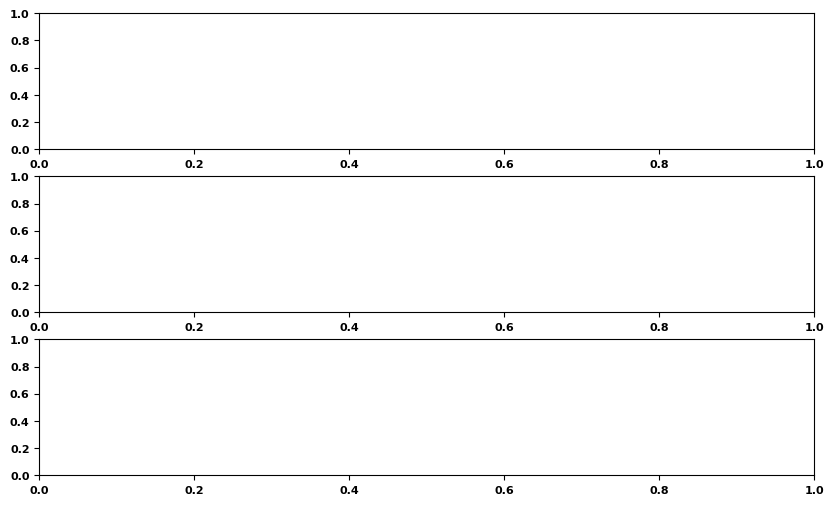

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tarfile
import pandas as pd
from scipy.interpolate import interp1d

plt.rcParams.update({
    'font.size': 8,
    "font.weight": "bold",
    'axes.labelsize': 'large',
    'axes.labelweight': 'bold'
})

def compute_energy_consump(test_data_frame):
    total_energy = 0
    for i, t in enumerate(test_data_frame['average_power']['elapsed_time'].iloc[:-1]):
        total_energy += test_data_frame['average_power']['average_power'].iloc[i] * \
                        (test_data_frame['average_power']['elapsed_time'].iloc[i+1] -
                         test_data_frame['average_power']['elapsed_time'].iloc[i])
    return total_energy

# Set up figure and average containers
fig_phase, axs_phase = plt.subplots(3, 1, figsize=(10, 6))

# Define a common time axis
common_time = np.linspace(0, 90, 500)

# Containers for interpolation results
progress_all, power_all, pcap_all = [], [], []

experiments = {'plotting_data_old': 'k'}
average_energy = 0
average_ET = 0

for dirs in experiments.keys():
    label_val = "Proposed Controller" if 'Control' in dirs else "Uncapped"
    DATA_DIR = get_data_dir(dirs)
    root, folders, files = next(os.walk(DATA_DIR))
    test_results = {}

    for APP in folders:
        if APP == 'ones-stream-full':
            APP_DIR = os.path.join(DATA_DIR, APP)
            test_results[APP] = {}

            for tar_file in next(os.walk(APP_DIR))[2]:
                test_results[APP][tar_file] = {}

                if tar_file.endswith('.tar'):
                    tar_path = os.path.join(APP_DIR, tar_file)
                    extract_dir = os.path.join(APP_DIR, tar_file[:-4])

                    if not os.path.exists(extract_dir):
                        os.makedirs(extract_dir)
                        with tarfile.open(tar_path, 'r') as tar:
                            tar.extractall(path=extract_dir)

                    # Load data
                    pubProgress = pd.read_csv(f'{extract_dir}/progress.csv')
                    pubEnergy = pd.read_csv(f'{extract_dir}/energy.csv')
                    pubPAPI = pd.read_csv(f'{extract_dir}/papi.csv')
                    pubPCAP = pd.read_csv(f'{extract_dir}/PCAP_file.csv')
                    pubPower = pd.read_csv(f'{extract_dir}/measured_power.csv')

                    # Process data
                    test_results[APP][tar_file]['energy'] = pubEnergy
                    test_results[APP][tar_file]['power'] = compute_power(pubEnergy)
                    test_results[APP][tar_file]['progress'] = measure_progress(pubProgress, test_results[APP][tar_file]['power'])
                    test_results[APP][tar_file]['papi'] = collect_papi(pubPAPI)
                    test_results[APP][tar_file]['PCAP'] = generate_PCAP(pubPCAP)
                    test_results[APP][tar_file]['sensed_power'] = collect_power(pubPower)

                    # Extract series
                    stop = -1
                    progress_df = test_results[APP][tar_file]['progress']['progress_frequency_median']
                    power_df = test_results[APP][tar_file]['sensed_power']['average_power']
                    pcap_df = test_results[APP][tar_file]['PCAP']

                    # Filter and plot as line plots (not scatter)
                    valid_progress = progress_df[progress_df['median'] >= 0]
                    valid_power = power_df[power_df['average_power'] >= 0]
                    valid_pcap = pcap_df[pcap_df['value'] >= 0]

                axs_phase[0].plot(valid_progress['elapsed_time'].iloc[:stop], valid_progress['median'].iloc[:stop], alpha=0.3, linewidth=1)
                axs_phase[1].plot(valid_power['elapsed_time'], valid_power['average_power'], alpha=0.3, linewidth=1)
                axs_phase[2].plot(valid_pcap['elapsed_time'].iloc[:stop], valid_pcap['value'].iloc[:stop], alpha=0.3, linewidth=1)
                # print(valid_pcap['elapsed_time'].iloc[-1])
                if valid_pcap['elapsed_time'].iloc[-1] > 150:
                    print(tar_file)
                # Interpolate for averaging

                progress_interp = interp1d(progress_df['elapsed_time'], progress_df['median'], bounds_error=False, fill_value='extrapolate')
                power_interp = interp1d(power_df['elapsed_time'], power_df['average_power'], bounds_error=False, fill_value='extrapolate')
                pcap_interp = interp1d(pcap_df['elapsed_time'], pcap_df['value'], bounds_error=False, fill_value='extrapolate')

            computed_energy = np.mean([
                compute_energy_consump(test_results[APP][trace]['power']) / 1000
                for trace in test_results[APP].keys()
            ])
            execution_time = np.mean([
                test_results[APP][trace]['power']['average_power']['elapsed_time'].iloc[-1]
                for trace in test_results[APP].keys()
            ])

        print("Computed Energy is:", computed_energy)
        print("Computed Execution Time is:", execution_time)

        # Plot average lines
        if progress_all:
            avg_progress = np.mean(progress_all, axis=0)
            avg_progress = np.clip(avg_progress, 0, None)
            axs_phase[0].plot(common_time[:-2], avg_progress[:-2], color='black', linewidth=2, label='Average')

        if power_all:
            avg_power = np.mean(power_all, axis=0)
            avg_power = np.clip(avg_power, 0, None)
            axs_phase[1].plot(common_time[:-2], avg_power[:-2], color='black', linewidth=2, label='Average')

        if pcap_all:
            avg_pcap = np.mean(pcap_all, axis=0)
            avg_pcap = np.clip(avg_pcap, 0, None)
            axs_phase[2].plot(common_time[:-2], avg_pcap[:-2], color='black', linewidth=2, label='Average')

        # Label axes
        axs_phase[0].set_ylabel("Progress [Hz]")
        axs_phase[1].set_ylabel("Measured Power [W]")
        axs_phase[2].set_ylabel("PCAP [W]")
        axs_phase[2].set_xlabel("Time [s]")

        # Grid and layout
        for ax in axs_phase:
            ax.grid(True)

        # Unique legend
        handles, labels = axs_phase[0].get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        fig_phase.legend(unique_labels.values(), unique_labels.keys(), loc='upper right',
                        bbox_to_anchor=(0.9, 0.75), bbox_transform=fig_phase.transFigure)

        plt.tight_layout()
        plt.savefig(f'{APP}_averaged.pdf', format='pdf', bbox_inches='tight')


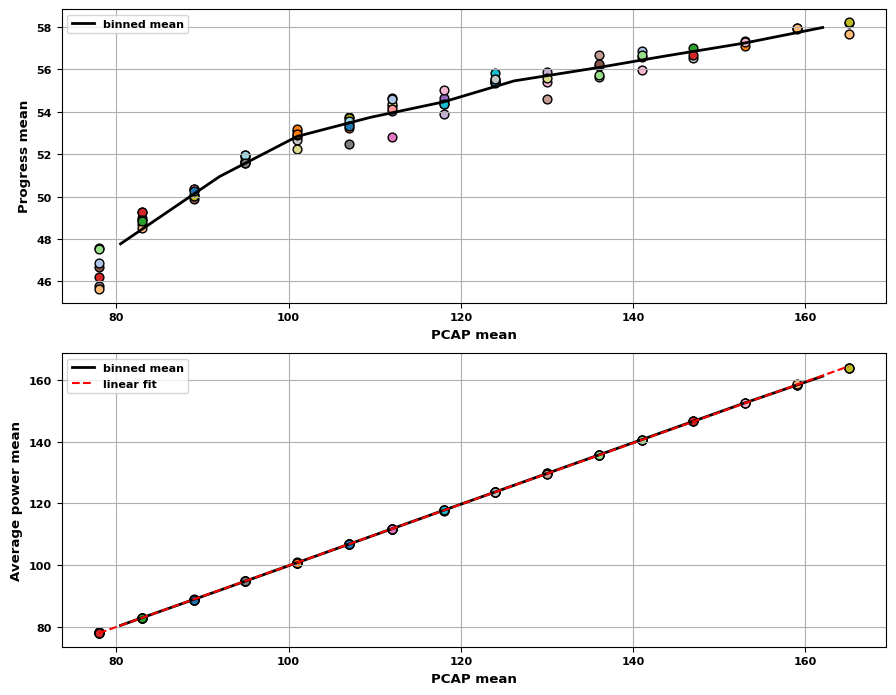

In [ ]:
# Plot per-trace scatter with consistent colors, binned averages and a linear fit
APP = 'ones-stream-full'
traces = list(test_results.get(APP, {}).keys())
if not traces:
    print("No traces for", APP)
else:
    # collect per-trace summary stats
    x = []  # mean PCAP per trace
    y_prog = []  # mean progress per trace
    y_power = []  # mean average_power per trace
    for t in traces:
        tr = test_results[APP][t]
        # safe extraction with fallbacks
        try:
            pcap_mean = float(tr['PCAP']['value'].mean())
        except Exception:
            pcap_mean = float('nan')
        try:
            prog_mean = float(tr['progress']['progress_frequency_median']['median'].mean())
        except Exception:
            prog_mean = float('nan')
        try:
            power_mean = float(tr['power']['average_power']['average_power'].mean())
        except Exception:
            power_mean = float('nan')
        x.append(pcap_mean); y_prog.append(prog_mean); y_power.append(power_mean)
    x = np.array(x); y_prog = np.array(y_prog); y_power = np.array(y_power)
    # plotting
    cmap = plt.get_cmap('tab20')
    fig, axs = plt.subplots(2,1, figsize=(9,7))
    # scatter: same color for corresponding trace across subplots
    for i, t in enumerate(traces):
        color = cmap(i % 20)
        if not np.isnan(x[i]) and not np.isnan(y_prog[i]):
            axs[0].scatter(x[i], y_prog[i], color=color, s=40, edgecolor='k')
        if not np.isnan(x[i]) and not np.isnan(y_power[i]):
            axs[1].scatter(x[i], y_power[i], color=color, s=40, edgecolor='k')
    # helper to compute and plot binned means
    def plot_binned_mean(ax, xarr, yarr, bins=10, color='black', label='binned mean'):
        mask = ~np.isnan(xarr) & ~np.isnan(yarr)
        if mask.sum() < 2:
            return
        xb = xarr[mask]; yb = yarr[mask]
        order = np.argsort(xb)
        xb = xb[order]; yb = yb[order]
        edges = np.linspace(xb.min(), xb.max(), bins+1)
        centers = []; means = []
        for k in range(bins):
            lo, hi = edges[k], edges[k+1]
            sel = (xb >= lo) & (xb < hi) if k < bins-1 else (xb >= lo) & (xb <= hi)
            if sel.sum() > 0:
                centers.append(xb[sel].mean()); means.append(yb[sel].mean())
        if centers:
            ax.plot(centers, means, color=color, linewidth=2, label=label)
    # plot binned means on both axes (use black)
    plot_binned_mean(axs[0], x, y_prog, bins=10, color='black', label='binned mean')
    plot_binned_mean(axs[1], x, y_power, bins=10, color='black', label='binned mean')
    # fit and plot linear regression line on axs[1] only
    def plot_fit_line(ax, xarr, yarr, color='red', label='linear fit'):
        mask = ~np.isnan(xarr) & ~np.isnan(yarr)
        if mask.sum() < 2:
            return
        coeff = np.polyfit(xarr[mask], yarr[mask], 1)
        xs = np.linspace(np.nanmin(xarr[mask]), np.nanmax(xarr[mask]), 200)
        ys = np.polyval(coeff, xs)
        ax.plot(xs, ys, color=color, linestyle='--', linewidth=1.5, label=label)
    # do NOT plot fit on axs[0] (user requested removal). Plot fit only on power subplot axs[1].
    plot_fit_line(axs[1], x, y_power, color='red', label='linear fit')
    axs[0].set_xlabel('PCAP mean')
    axs[0].set_ylabel('Progress mean')
    axs[1].set_xlabel('PCAP mean')
    axs[1].set_ylabel('Average power mean')
    for ax in axs:
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()


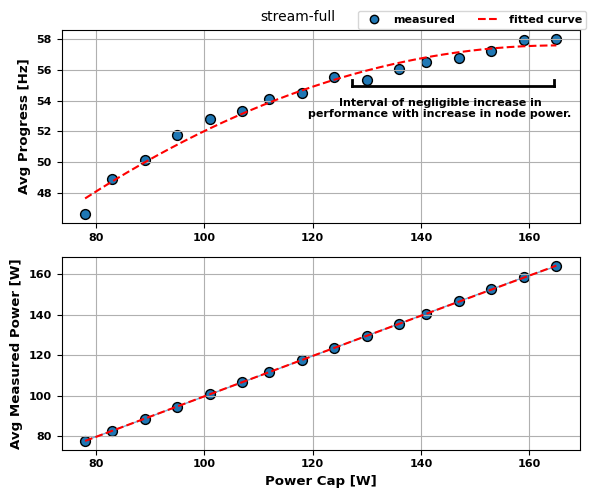

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.lines as mlines

# Try to import LOWESS; if unavailable we'll fallback to polynomial fits
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
except Exception:
    lowess = None

APP = 'ones-stream-full'

# Containers for grouping by PCAP
pcap_to_progress = defaultdict(list)
pcap_to_power = defaultdict(list)

# Step 1: collect means for each test run
for file in test_results.get(APP, {}).keys():
    try:
        pcap_val = float(test_results[APP][file]['PCAP'].value.mean())
    except Exception:
        continue

    try:
        progress_val = float(test_results[APP][file]['progress']['progress_frequency_median']['median'].mean())
    except Exception:
        progress_val = np.nan
    try:
        power_val = float(test_results[APP][file]['power']['average_power']['average_power'].mean())
    except Exception:
        power_val = np.nan

    pcap_to_progress[pcap_val].append(progress_val)
    pcap_to_power[pcap_val].append(power_val)

# Step 2: average within each PCAP group
pcap_vals = []
avg_progress_vals = []
avg_power_vals = []
for pcap in sorted(pcap_to_progress.keys()):
    pcap_vals.append(pcap)
    # use nanmean to guard against nan entries
    avg_progress_vals.append(np.nanmean(pcap_to_progress[pcap]))
    avg_power_vals.append(np.nanmean(pcap_to_power[pcap]))

# Convert to numpy arrays and sort by PCAP
x = np.array(pcap_vals)
y_prog = np.array(avg_progress_vals)
y_power = np.array(avg_power_vals)
if x.size == 0:
    print(f"No data available for APP={APP}")
else:
    order = np.argsort(x)
    x_s = x[order]; y_prog_s = y_prog[order]; y_power_s = y_power[order]

    # collapse duplicates (if any) by averaging y-values for identical x
    def collapse_duplicates(xs, ys):
        ux, inv = np.unique(xs, return_inverse=True)
        yux = np.array([ys[inv == i].mean() for i in range(len(ux))])
        return ux, yux

    x_s_u, y_prog_u = collapse_duplicates(x_s, y_prog_s)
    _, y_power_u = collapse_duplicates(x_s, y_power_s)

    # Step 3: plot (scatter with same color, connect averaged points and fit a LOWESS curve)
    fig, axs = plt.subplots(2, 1, figsize=(6, 5))
    color = 'tab:blue'
    

    # Progress subplot
    axs[0].scatter(x_s_u, y_prog_u, c=color, edgecolors='k', s=50, label='mean progress')

    # Use LOWESS when >=4 unique points, fallback to quadratic (3 pts) or linear (2 pts)
    if x_s_u.size >= 4 and lowess is not None:
        # frac heuristic: more points -> smaller frac; clamp to [0.1, 0.6]
        frac = float(min(0.6, max(0.1, 4.0 / max(4.0, x_s_u.size))))
        try:
            low = lowess(y_prog_u, x_s_u, frac=frac, return_sorted=True)
            # low is an array [[x_i, y_i_smooth],...], interpolate to a dense xs grid
            xs_raw = low[:, 0]
            ys_raw = low[:, 1]
            xs = np.linspace(x_s_u.min(), x_s_u.max(), 400)
            ys = np.interp(xs, xs_raw, ys_raw)
            axs[0].plot(xs, ys, color='red', linestyle='--', linewidth=1.5, label=f'LOWESS (frac={frac:.2f})')
        except Exception:
            # fallback to quadratic
            coeff_quad = np.polyfit(x_s_u, y_prog_u, 2)
            xs = np.linspace(x_s_u.min(), x_s_u.max(), 400)
            ys = np.polyval(coeff_quad, xs)
            axs[0].plot(xs, ys, color='red', linestyle='--', linewidth=1.5, label='quad fallback')
    elif x_s_u.size >= 4 and lowess is None:
        # statsmodels not available; fallback to Univariate/polyfit approach (quadratic smoothing)
        coeff_quad = np.polyfit(x_s_u, y_prog_u, 2)
        xs = np.linspace(x_s_u.min(), x_s_u.max(), 400)
        ys = np.polyval(coeff_quad, xs)
        axs[0].plot(xs, ys, color='red', linestyle='--', linewidth=1.5, label='quad fallback (no LOWESS)')
    elif x_s_u.size == 3:
        coeff_quad = np.polyfit(x_s_u, y_prog_u, 2)
        xs = np.linspace(x_s_u.min(), x_s_u.max(), 400)
        ys = np.polyval(coeff_quad, xs)
        axs[0].plot(xs, ys, color='red', linestyle='--', linewidth=1.5, label='quadratic fit')
    elif x_s_u.size == 2:
        coeff = np.polyfit(x_s_u, y_prog_u, 1)
        xs = np.linspace(x_s_u.min(), x_s_u.max(), 400)
        ys = np.polyval(coeff, xs)
        axs[0].plot(xs, ys, color='red', linestyle='--', linewidth=1.5, label='linear fit')

    # --- Annotation: bracket and explanatory text on the flat side of the progress plot ---
    # Coordinates are in axis fraction (0..1). Adjust br_x0/br_x1/br_y_* to move bracket.
    br_x0, br_x1 = 0.56, 0.95
    br_y_top, br_y_bottom = 0.74, 0.71
    axs[0].plot([br_x0, br_x0], [br_y_top, br_y_bottom], transform=axs[0].transAxes, color='k', linewidth=2)
    axs[0].plot([br_x0, br_x1], [br_y_bottom, br_y_bottom], transform=axs[0].transAxes, color='k', linewidth=2)
    axs[0].plot([br_x1, br_x1], [br_y_bottom, br_y_top], transform=axs[0].transAxes, color='k', linewidth=2)
    annotation_text = (
        'Interval of negligible increase in\n'
        'performance with increase in node power.'
    )
    axs[0].text(0.73, 0.65, annotation_text, transform=axs[0].transAxes,
                fontsize=8, ha='center', va='top', wrap=True)
    # --------------------------------------------------------------------------------------

    # remove x-label from top subplot (shared x-axis with bottom)
    # axs[0].set_xlabel("Power Cap [W]")  # intentionally removed
    axs[0].set_ylabel("Avg Progress [Hz]")
    axs[0].grid(True)

    # Power subplot
    axs[1].scatter(x_s_u, y_power_u, c=color, edgecolors='k', s=50, label='mean power')
    axs[1].plot(x_s_u, y_power_u, color=color, linewidth=1, alpha=0.6)

    if x_s_u.size >= 4 and lowess is not None:
        frac2 = float(min(0.6, max(0.1, 4.0 / max(4.0, x_s_u.size))))
        try:
            low2 = lowess(y_power_u, x_s_u, frac=frac2, return_sorted=True)
            xs2_raw = low2[:, 0]
            ys2_raw = low2[:, 1]
            xs2 = np.linspace(x_s_u.min(), x_s_u.max(), 400)
            ys2 = np.interp(xs2, xs2_raw, ys2_raw)
            axs[1].plot(xs2, ys2, color='red', linestyle='--', linewidth=1.5, label=f'LOWESS (frac={frac2:.2f})')
        except Exception:
            coeff2_quad = np.polyfit(x_s_u, y_power_u, 2)
            xs2 = np.linspace(x_s_u.min(), x_s_u.max(), 400)
            ys2 = np.polyval(coeff2_quad, xs2)
            axs[1].plot(xs2, ys2, color='red', linestyle='--', linewidth=1.5, label='quad fallback')
    elif x_s_u.size >= 4 and lowess is None:
        coeff2_quad = np.polyfit(x_s_u, y_power_u, 2)
        xs2 = np.linspace(x_s_u.min(), x_s_u.max(), 400)
        ys2 = np.polyval(coeff2_quad, xs2)
        axs[1].plot(xs2, ys2, color='red', linestyle='--', linewidth=1.5, label='quad fallback (no LOWESS)')
    elif x_s_u.size == 3:
        coeff2_quad = np.polyfit(x_s_u, y_power_u, 2)
        xs2 = np.linspace(x_s_u.min(), x_s_u.max(), 400)
        ys2 = np.polyval(coeff2_quad, xs2)
        axs[1].plot(xs2, ys2, color='red', linestyle='--', linewidth=1.5, label='quadratic fit')
    elif x_s_u.size == 2:
        coeff2 = np.polyfit(x_s_u, y_power_u, 1)
        xs2 = np.linspace(x_s_u.min(), x_s_u.max(), 400)
        ys2 = np.polyval(coeff2, xs2)
        axs[1].plot(xs2, ys2, color='red', linestyle='--', linewidth=1.5, label='linear fit')

    axs[1].set_xlabel("Power Cap [W]")
    axs[1].set_ylabel("Avg Measured Power [W]")
    axs[1].grid(True)

    # Create a single legend for both subplots: measured (dots) and fitted curve (line)
    dot_handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                            markeredgecolor='k', markersize=6)
    line_handle = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1.5)

    fig.legend(
        [dot_handle, line_handle],
        ['measured', 'fitted curve'],
        loc='upper right',
        bbox_to_anchor=(0.99, 0.99),
        ncol=2,              # <-- forces the legend into one horizontal row
        frameon=True,
        fontsize=8
    )
    # Add figure title
    fig.suptitle('stream-full', fontsize=10)

    # Reduce spacing between title and plots
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(top=0.94)   # move plots closer to title (try 0.88–0.92)

    plt.show()

    fig.savefig(f'{APP}_pcap_analysis.pdf', format='pdf', bbox_inches='tight')
